# # **Cálculo de Densidad desde un Archivo GSD (HOOMD-blue)**

In [1]:
# 1. Importar las librerías necesarias
import os

In [2]:
# Propiedades análisis
polimerizacion = [8, 16, 24]
temperaturas = [0.60, 0.65]

archivos = []
for polim in polimerizacion:
    for temp in temperaturas:
        estructura_arch = f'Poly-Solv_T{temp:.2f}_epsSP1.00_monom_{polim}.gsd'
        archivos.append(estructura_arch)

print(archivos)
print(len(archivos))

['Poly-Solv_T0.60_epsSP1.00_monom_8.gsd', 'Poly-Solv_T0.65_epsSP1.00_monom_8.gsd', 'Poly-Solv_T0.60_epsSP1.00_monom_16.gsd', 'Poly-Solv_T0.65_epsSP1.00_monom_16.gsd', 'Poly-Solv_T0.60_epsSP1.00_monom_24.gsd', 'Poly-Solv_T0.65_epsSP1.00_monom_24.gsd']
6


In [3]:
# Busqueda de archivos
ruta_memoria = '/run/media/fabio-noriega/Almacen_Fabio/Simulaciones/Resultados/Polymers/P12_Polimero_Solvente'
ruta_codigo = '/home/fabio-noriega/Coding/CIATEC/Molecular-Dinamics'


# Filtrado de archivos encontrados
archivos_encontrados = []
for archivo in archivos:
    os.chdir(os.path.join(ruta_memoria))
    if not os.path.exists(archivo):
        print(f'No se encontró el archivo: {archivo}')
    else:
        archivos_encontrados.append(archivo)

os.chdir(ruta_codigo)
print(os.getcwd()) 


/home/fabio-noriega/Coding/CIATEC/Molecular-Dinamics


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Procesando 67 frames para las especies: ['S', 'P']...


/tmp/ipykernel_48901/3565541459.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('prism', len(archivos_encontrados))


Frame procesado: 160/167
✅ Cálculo completado con éxito.
>> Poly-Solv_T0.60_epsSP1.00_monom_8.gsd

--------------------
--------------------
Procesando 46 frames para las especies: ['S', 'P']...
Frame procesado: 140/146
✅ Cálculo completado con éxito.
>> Poly-Solv_T0.65_epsSP1.00_monom_8.gsd

--------------------
--------------------
Procesando 121 frames para las especies: ['S', 'P']...
Frame procesado: 220/221
✅ Cálculo completado con éxito.
>> Poly-Solv_T0.60_epsSP1.00_monom_16.gsd

--------------------
--------------------
Procesando 121 frames para las especies: ['S', 'P']...
Frame procesado: 220/221
✅ Cálculo completado con éxito.
>> Poly-Solv_T0.65_epsSP1.00_monom_16.gsd

--------------------
--------------------
Procesando 101 frames para las especies: ['S', 'P']...
Frame procesado: 200/201
✅ Cálculo completado con éxito.
>> Poly-Solv_T0.60_epsSP1.00_monom_24.gsd

--------------------
--------------------
Procesando 104 frames para las especies: ['S', 'P']...
Frame procesado: 2

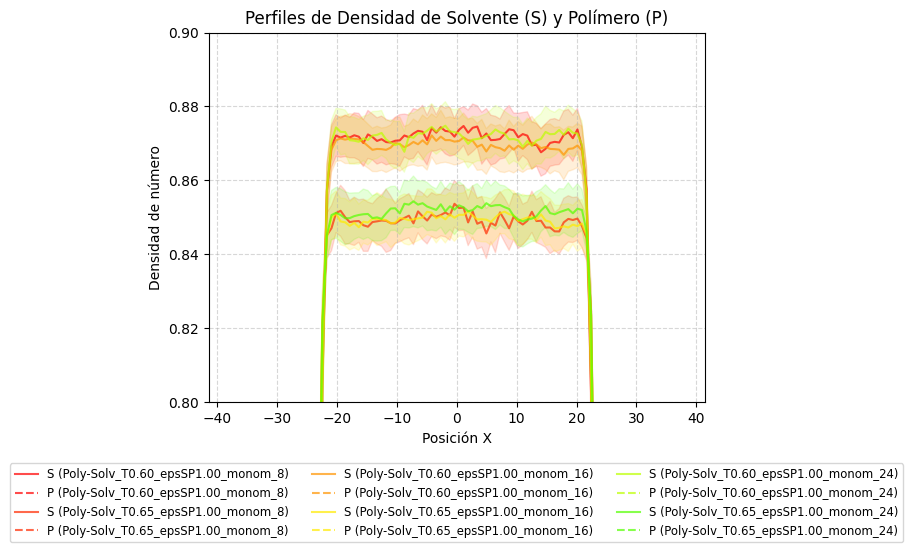

In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from funciones import calcular_perfil_densidad_multi_especie

figura, ax = plt.subplots()
especies = ['S', 'P']

# Tomamos un color para cada simulacion
colormap = plt.cm.get_cmap('prism', len(archivos_encontrados))

# Asignamos los estilos de línea para las especies
estilos_linea = {'S': '-',  'P': '--'} # Sólida para Solvente, Discontinua para Polímero

# Determinación de perfil de densidad
for idx, archivo in enumerate(archivos_encontrados):
    os.chdir(os.path.join(ruta_memoria))

    centros_x, resultados = calcular_perfil_densidad_multi_especie(gsd_file=archivo, tipos_interes=especies, start_frame=100)
    print(f'>> {archivo}\n')

    # El color asignado de manera única a ESTE archivo
    color_archivo = colormap(idx)

    for especie in especies:
        promedio = resultados[especie]['promedio']
        desviacion = resultados[especie]['desviacion']

        y1 = promedio - desviacion
        y2 = promedio + desviacion

        # Simplificamos un poco el nombre del archivo en la leyenda para que no sea kilométrico
        # (Quitamos el ".gsd" al final para limpiar el texto)
        nombre_corto = archivo.replace('.gsd', '')
        etiqueta = f"{especie} ({nombre_corto})"

        # Graficado de la línea promedio
        ax.plot(centros_x, promedio, label=etiqueta, color=color_archivo, 
                linestyle=estilos_linea[especie],alpha=0.7)
        
        # Sombreado de la desviación estándar (alpha bajo para que sea transparente)
        ax.fill_between(centros_x, y1, y2, color=color_archivo, alpha=0.15)

        print('-'*20)

# Configuraciones finales del gráfico
ax.set_xlabel("Posición X")
ax.set_ylabel("Densidad de número")
ax.set_title("Perfiles de Densidad de Solvente (S) y Polímero (P)")

ax.legend(
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=3, 
    fontsize='small'
)

ax.grid(True, linestyle='--', alpha=0.5)
ax.set(ylim=(0.8, 0.9))


plt.show()
